# Training Baseline:
- Read the two artifacts from `01_data_eda.ipynb` notebook as the ground-truth input of the whole project:
-  `/experiments/pools/source_pool_rel.csv`
-  `/experiments/pools/preprocessing_config.json`
- Build the Dataset class (`CXRThreeClassDataset`).
- Define the shared preprocessing transforms (ImageNet normalisation, etc).
- Createss *train/val DataLoaders* for a single *80/20* split.
This keeps **everything in memory**. No saving of models, metrics, or new CSVs.
This notebook role is purely to verify that those artifacts load correctly and yield balanced splits.

 ## 1. Overview: Preprocessing rationale.

This notebook loads the preprocessing configuration saved during EDA.
All experiments use:
- 256×256 RGB inputs (or 320×320 for sensitivity analysis).
- ImageNet normalisation (mean/std).
- Unified three-class mapping: Pneumonia (CheXpert), TB and Normal (TBX11K).

Below, the configuration is automatically loaded from /experiments/pools/`preprocessing_config.json`.

In [1]:
# Define a reproducible preprocessing pipeline for training and validation/testing.

# Toggle here for running the sensitivity analysis.
IMG_SIZE = 256 # Set to 320 for the sensitivity analysis.

print(f'Preprocessing ready at {IMG_SIZE}x{IMG_SIZE} RGB.')
print(f'- CheXpert: grayscale -> RGB + normalisation.')
print(f'- TBX11K  : RGB + normalisation.')

# Clarify the modelling classes and their data sources (for logging/record-keeping).
print("\nClasses that will be used for training: \n- 'Pneumonia' (CheXpert frontal-only)\n- 'Normal' (TBX11K) \n- 'TB' (TBX11K)")

Preprocessing ready at 256x256 RGB.
- CheXpert: grayscale -> RGB + normalisation.
- TBX11K  : RGB + normalisation.

Classes that will be used for training: 
- 'Pneumonia' (CheXpert frontal-only)
- 'Normal' (TBX11K) 
- 'TB' (TBX11K)


## 2a. Load Artefacts and **Normalisation Toggle**.
Load persisted EDA artefacts to rebuild the unified dataset and ensure reproducibility.
#### Rationale:
- Reuse saved files (source_pool_rel.csv, preprocessing_config.json) instead of regenerating them.
- Add a toggle to switch between:
    - ImageNet stats: for pretrained models (MobileNetV2, EfficientNet-B0, ResNet-50).
    - CXR stats: for custom CNNs using dataset-specific mean/std.
- Maintain consistent preprocessing across all experiments.

In [2]:
# Build a unified three-class Dataset using RELATIVE paths (mirror 01_data_eda.ipynb behavior).
# Instead of reconstructing DataFrames again, load the already persisted artefacts produced by EDA.
# This ensures reproducibility and avoids duplication of logic between notebooks.

from pathlib import Path
import pandas as pd
import torch
from torch.utils.data import Dataset
from PIL import Image
import json

# --- Load persisted artefacts from EDA (source_pool_rel.csv + preprocessing_config.json) ---.
PROJECT_ROOT = Path("..").resolve()
CHEXPERT_PATH = PROJECT_ROOT / "data" / "chexpert"
TBX11K_PATH = PROJECT_ROOT / "data" / "tbx11k"

# Load the unified pool with relative paths, class names, and source tags.
source_pool_rel = pd.read_csv(PROJECT_ROOT / "experiments" / "pools" / "source_pool_rel.csv")

# Load preprocessing config (IMG_SIZE, ImageNet stats, label map).
with open(PROJECT_ROOT / "experiments" / "pools" / "preprocessing_config.json", "r") as f:
    cfg = json.load(f)

CLASS_TO_INDEX = {k: int(v) for k, v in cfg["class_to_index"].items()}
INDEX_TO_CLASS = {v: k for k, v in CLASS_TO_INDEX.items()}

print("Loaded persisted EDA artefacts successfully:")
print(f'- Classes: {CLASS_TO_INDEX}')
print(f'- IMG_SIZE: {cfg["img_size"]}')
print(f'- Transform mode: {cfg["transform_mode"]}')
print(f'- Total samples: {len(source_pool_rel):,}')

# --- Choose normalisation source ---
# Allows flexible selection of mean/std parameters for preprocessing.
# Set USE_IMAGENET_STATS = True to reproduce pretrained baselines (MobileNetV2, EfficientNet-B0, ResNet-50).
# Set to False to use dataset-specific statistics computed in 01_data_eda.ipynb (for custom CNNs).

USE_IMAGENET_STATS = True  # Change manually when needed.

if USE_IMAGENET_STATS:
    MEAN = cfg["imagenet_mean"]
    STD  = cfg["imagenet_std"]
    source = "ImageNet"
else:
    MEAN = cfg["cxr_mean"]
    STD  = cfg["cxr_std"]
    source = "CXR (dataset-specific)"

print(f"\nUsing {source} normalisation:")
print(f"  mean = {MEAN}")
print(f"  std  = {STD}")

Loaded persisted EDA artefacts successfully:
- Classes: {'Pneumonia': 0, 'TB': 1, 'Normal': 2}
- IMG_SIZE: 256
- Transform mode: letterbox
- Total samples: 13,521

Using ImageNet normalisation:
  mean = [0.485, 0.456, 0.406]
  std  = [0.229, 0.224, 0.225]


## 2b. Normalisation Toggle:
Compute once and reuse the same preprocessing configuration for all experiments.
#### Rationale:
- Allow the same pipeline to operate in two modes:
    - ImageNet statistics (USE_IMAGENET_STATS = True): for transfer learning with pretrained backbones (MobileNetV2, EfficientNet-B0, ResNet-50).
    - CXR dataset statistics (USE_IMAGENET_STATS = False): for training custom CNNs from scratch using the global mean and standard deviation computed in 01_data_eda.ipynb.

- Ensure reproducibility and fair comparison between pretrained and dataset-specific normalisation strategies.
- Keep preprocessing consistent across notebooks and experiments.

In [3]:
# Unified Dataset class.
class CXRThreeClassDataset(Dataset):
    """
    Provide a unified three-class CXR dataset with the fixed label order:
      0 : 'Pneumonia' (CheXpert frontal-only)
      1 : 'TB'        (TBX11K)
      2 : 'Normal'    (TBX11K)

    Absolute paths are built at access time depending on the "Source" column.
    This class implements the standard PyTorch Dataset API (len, getitem).
    """

    def __init__(self, items: pd.DataFrame, transforms, chexpert_root: Path, tbx_root: Path):
        # Store the DataFrame of items (relative paths + labels + sources).
        # Resetting the index ensures sequential indices from 0...n-1 for safe access.
        self.items = items.reset_index(drop=True)

        # Save preprocessing transforms (data augmentation / normalisation).
        self.transforms = transforms

        # Save root paths to both datasets: need to build absolute paths later.
        self.chexpert_root = chexpert_root
        self.tbx_root = tbx_root

    def __len__(self) -> int:
        # Required by PyTorch: return the total number of samples in the dataset.
        return len(self.items)

    def __getitem__(self, idx: int):
        # Fetch the metadata for a single sample (row from the DataFrame).
        row = self.items.iloc[idx]

        # Build the absolute file path:
        # - If from CheXpert, join with CheXpert root.
        # - If from TBX11K, join with tbx_root + "imgs" folder.
        abs_path = (
            self.chexpert_root / row["rel_path"]
            if row["Source"] == "chexpert"
            else self.tbx_root / "imgs" / row["rel_path"]
        )

        # Load the image and convert to RGB explicitly.
        # This ensures grayscale CheXpert images become 3-channel, consistent with TBX11K and ImageNet.
        img = Image.open(abs_path).convert("RGB")

        # Apply preprocessing transforms if provided (resize, normalise, augment).
        if self.transforms is not None:
            img = self.transforms(img)

        # Convert the class string (e.g., "TB") into its numeric index (0/1/2).
        label = CLASS_TO_INDEX[row["Class"]]

        # Return a tuple (image tensor, label tensor) ready for PyTorch DataLoader.
        return img, torch.tensor(label, dtype=torch.long)

# --- Instantiate the unified PyTorch Dataset over the full pool ---
train_dataset = CXRThreeClassDataset(
    items=source_pool_rel, # Full unified table created during 01_data_eda.ipynb.
    transforms=None,  # Temporarily none; it will attach shared transform later.
    chexpert_root=CHEXPERT_PATH, # Root path for CheXpert dataset.
    tbx_root=TBX11K_PATH # Root path for TBX11K dataset.
)

# Report readiness: dataset length and label order mapping.
print(f'\nCXRThreeClassDataset ready (relative-path mode): {len(train_dataset)} samples, label order={INDEX_TO_CLASS}')


CXRThreeClassDataset ready (relative-path mode): 13521 samples, label order={0: 'Pneumonia', 1: 'TB', 2: 'Normal'}


## 3. Share Preprocessing (Unified Train/Eval Transforms).
Define a single train/eval pipeline at 256×256 RGB with ImageNet normalisation. Preserve aspect ratio and use a centre crop (deterministic) to avoid chopping diagnostically important borders.
#### Rationale:
- Enforce identical preprocessing across sources to avoid domain-specific bias.
- Align inputs with ImageNet-pretrained backbones (RGB + mean/std) for stable transfer.
- Preserve aspect ratio on resize; prefer centre crop over random crop to keep anatomy intact (apices, costophrenic angles, etc.).
- Apply minimal, label-safe augmentation (random horizontal flip) suitable for frontal CXRs.

In [4]:
# Shared transforms for BOTH datasets (CheXpert + TBX11K), using parameters loaded from the persisted config.
# This ensures identical preprocessing across all experiments and notebooks.
# The transforms enforce RGB input, normalisation (ImageNet or CXR depending on toggle), and safe horizontal flipping for frontal CXRs.

from torchvision.transforms import InterpolationMode
from torchvision import transforms as T

# Extract image size directly from the loaded configuration (cfg).
IMG_SIZE = int(cfg["img_size"])

train_transforms_shared = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR, antialias=True),  # Scale shortest side to IMG_SIZE (preserve aspect).
                                                                                   # Smooth resize.
    T.CenterCrop(IMG_SIZE),  # Deterministic crop; keeps central anatomy.
    T.RandomHorizontalFlip(p=0.5),  # Safe augmentation for frontal CXRs.
    T.ToTensor(),  # HWC (Height, Width, Channel -> CHW (Channel, Height, Width)), convert to tensor [0..1].
    T.Normalize(MEAN, STD)  # Use mean/std based on toggle defined above (ImageNet or CXR).
])

eval_transforms_shared = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR, antialias=True),  # Preserve aspect ratio.
    T.CenterCrop(IMG_SIZE),  # Deterministic crop for evaluation.
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

# Attach to the current dataset instance (created above).
train_dataset.transforms = train_transforms_shared  # Use shared training pipeline now.

print(f'Transforms attached successfully: {IMG_SIZE}x{IMG_SIZE} with "{"ImageNet" if USE_IMAGENET_STATS else "CXR"}" normalisation.')

Transforms attached successfully: 256x256 with "ImageNet" normalisation.


## 4. Sanity Check: Verify Shared Transforms Are Applied.
Fetch one item per source via `train_dataset` and inspect tensor properties.
#### Rationale:
- Confirm output shape is (3, 256, 256) and dtype is `float32`.
- Confirm values are normalised (roughly centred near 0).
- Ensure CheXpert (grayscale) arrives as RGB after conversion.
- Catch any path/IO issue early.

CheXpert sample: shape=(3, 256, 256), dtype=torch.float32, label=0
  mean=0.530, std=1.187, min=-2.118, max=2.640
TBX11K sample: shape=(3, 256, 256), dtype=torch.float32, label=1
  mean=-0.040, std=1.269, min=-2.118, max=2.326


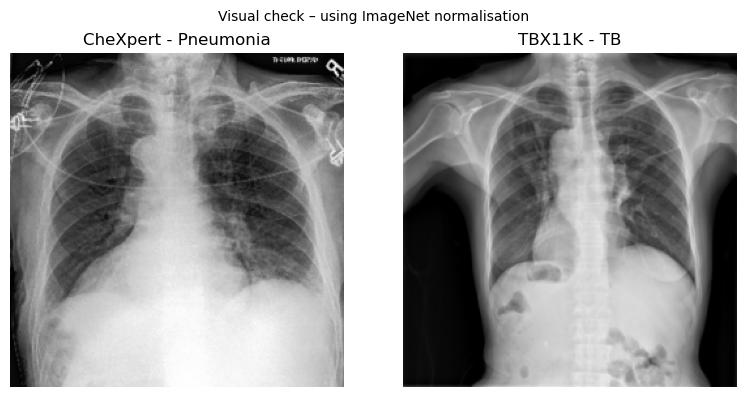

In [5]:
# Sanity-check a CheXpert and TBX11K sample after transforms (no images saved).
import torch
import matplotlib.pyplot as plt

# Find one index per source from the dataset's items table.
chex_idx = train_dataset.items.index[train_dataset.items["Source"] == "chexpert"][0]
tbx_idx  = train_dataset.items.index[train_dataset.items["Source"] == "tbx11k"][0]

# Pull samples (applied current train_dataset.transforms).
x_chex, y_chex = train_dataset[chex_idx]
x_tbx, y_tbx   = train_dataset[tbx_idx]

def summ(name, x, y):
    print(f'{name}: shape={tuple(x.shape)}, dtype={x.dtype}, label={int(y)}')
    # Quick stats on a small subset of elements to avoid huge prints.
    t = x.flatten()
    print(f'  mean={t.mean().item():.3f}, std={t.std().item():.3f}, min={t.min().item():.3f}, max={t.max().item():.3f}')

summ("CheXpert sample", x_chex, y_chex)
summ("TBX11K sample", x_tbx, y_tbx)

# --- Show the images below (inverse-normalise) ---
# Use the same mean/std selected earlier via the USE_IMAGENET_STATS toggle.
image_mean = torch.tensor(MEAN).view(3, 1, 1)
image_std  = torch.tensor(STD).view(3, 1, 1)

def denorm_np(x: torch.Tensor):
    # Invert normalisation for visualisation
    x = (x * image_std + image_mean).clamp(0, 1)
    return x.permute(1, 2, 0).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(denorm_np(x_chex)); ax[0].axis("off"); ax[0].set_title(f'CheXpert - {INDEX_TO_CLASS[int(y_chex)]}')
ax[1].imshow(denorm_np(x_tbx));  ax[1].axis("off"); ax[1].set_title(f'TBX11K - {INDEX_TO_CLASS[int(y_tbx)]}')
plt.suptitle(f"Visual check – using {'ImageNet' if USE_IMAGENET_STATS else 'CXR'} normalisation", fontsize=10)
plt.tight_layout(); plt.show()

## 5. Load Clean Train/Val/Test Splits (Deduplicated and Final)
Load the final train, validation, and test partitions produced in Notebook 01 using perceptual-hash deduplication. These CSV files define a stable, leakage-free dataset split that ensures all three evaluation stages operate on mutually exclusive images. Using precomputed splits also makes the training pipeline deterministic and fully reproducible across runs and machines.
#### Rationale:
- Ensures no train/val/test leakage, because all splits were created after removing perceptual duplicates from the unified pool.
- Guarantees reproducibility, since splits are stored as CSV files rather than recomputed at runtime.
- Enforces consistent preprocessing by applying the same class map and image transforms used in previous notebooks.
- Supports proper generalisation testing, by keeping the test set entirely unseen until Notebook 04.
- Produces DataLoaders optimised for GPU training (parallel workers, pinned memory, persistent workers).

In [10]:
# 5. Load Clean Train/Val/Test Splits (Deduplicated, No Re-splitting).
import sys
from pathlib import Path

# Ensure repo root is visible BEFORE importing src.
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
from torch.utils.data import DataLoader
from src.dataset import CXRThreeClassDataset

print("PROJECT_ROOT added to sys.path:", PROJECT_ROOT)

# 1. Load the cleaned CSV splits generated in Notebook 01 (after deduplication).
splits_dir = PROJECT_ROOT / "experiments" / "pools"

train_df = pd.read_csv(splits_dir / "train_split.csv")
val_df   = pd.read_csv(splits_dir / "val_split.csv")
test_df  = pd.read_csv(splits_dir / "test_split.csv")

# 2. Build dataset objects
train_dataset = CXRThreeClassDataset(
    train_df,
    CLASS_TO_INDEX,
    transforms=train_transforms_shared,
    chexpert_root=CHEXPERT_PATH,
    tbx_root=TBX11K_PATH
)

val_dataset = CXRThreeClassDataset(
    val_df,
    CLASS_TO_INDEX,
    transforms=eval_transforms_shared,
    chexpert_root=CHEXPERT_PATH,
    tbx_root=TBX11K_PATH
)

test_dataset = CXRThreeClassDataset(
    test_df,
    CLASS_TO_INDEX,
    transforms=eval_transforms_shared,
    chexpert_root=CHEXPERT_PATH,
    tbx_root=TBX11K_PATH
)

# 3. Build DataLoaders.
train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True,
    num_workers=8, pin_memory=True, persistent_workers=True
)

val_loader = DataLoader(
    val_dataset, batch_size=64, shuffle=False,
    num_workers=4, pin_memory=True, persistent_workers=True
)

test_loader = DataLoader(
    test_dataset, batch_size=64, shuffle=False,
    num_workers=4, pin_memory=True, persistent_workers=True
)

print("Loaders ready - using deduplicated CSV splits. No leakage. No re-splitting.")

PROJECT_ROOT added to sys.path: /lab/px/msc-sept-24-ft-cohort-capstone-chrisanich
Loaders ready - using deduplicated CSV splits. No leakage. No re-splitting.
